<a href="https://colab.research.google.com/github/Manasa23BEIS123/AIML-12-Week-Program/blob/feat%2Faiml-W4-Manasa/W4D1_Model_Evaluation_Metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# W4D1: Model Evaluation Metrics
# Topics: Precision, Recall, ROC-AUC,
# K-Fold CV, Stratified CV, Learning Curves

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    cross_val_score,
    learning_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
# Create a synthetic binary classification dataset

X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_classes=2,
    random_state=42
)

print("Dataset shape:", X.shape)
print("Target shape:", y.shape)

print("\nClass distribution:")
print(pd.Series(y).value_counts())

Dataset shape: (1000, 10)
Target shape: (1000,)

Class distribution:
1    502
0    498
Name: count, dtype: int64


In [3]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 800
Testing samples: 200


In [4]:
# Create a pipeline with feature scaling and Logistic Regression

model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(random_state=42))
])

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Model trained successfully!")

Model trained successfully!


In [5]:
# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

Accuracy : 0.8200
Precision: 0.7909
Recall   : 0.8700
ROC-AUC  : 0.8797


In [6]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.77      0.81       100
           1       0.79      0.87      0.83       100

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.82      0.82      0.82       200



In [7]:
# K-Fold Cross-Validation

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=kf,
    scoring="accuracy"
)

print("K-Fold Accuracy Scores:")
print(cv_scores)

print(f"\nMean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

K-Fold Accuracy Scores:
[0.8   0.835 0.815 0.825 0.855]

Mean Accuracy: 0.8260
Standard Deviation: 0.0185


In [8]:
# Stratified K-Fold Cross-Validation

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

stratified_scores = cross_val_score(
    model,
    X,
    y,
    cv=skf,
    scoring="accuracy"
)

print("Stratified K-Fold Accuracy Scores:")
print(stratified_scores)

print(f"\nMean Accuracy: {stratified_scores.mean():.4f}")
print(f"Standard Deviation: {stratified_scores.std():.4f}")

Stratified K-Fold Accuracy Scores:
[0.84  0.81  0.795 0.845 0.835]

Mean Accuracy: 0.8250
Standard Deviation: 0.0192


In [9]:
# Compare Cross-Validation Results

comparison = pd.DataFrame({
    "Method": [
        "K-Fold",
        "Stratified K-Fold"
    ],
    "Mean Accuracy": [
        cv_scores.mean(),
        stratified_scores.mean()
    ],
    "Std Deviation": [
        cv_scores.std(),
        stratified_scores.std()
    ]
})

comparison

,Method,Mean Accuracy,Std Deviation
0,K-Fold,0.826,0.018547
1,Stratified K-Fold,0.825,0.019235


In [10]:
# Evaluate multiple metrics using Stratified K-Fold

precision_scores = cross_val_score(
    model,
    X,
    y,
    cv=skf,
    scoring="precision"
)

recall_scores = cross_val_score(
    model,
    X,
    y,
    cv=skf,
    scoring="recall"
)

auc_scores = cross_val_score(
    model,
    X,
    y,
    cv=skf,
    scoring="roc_auc"
)

metrics_comparison = pd.DataFrame({
    "Metric": ["Precision", "Recall", "ROC-AUC"],
    "Mean Score": [
        precision_scores.mean(),
        recall_scores.mean(),
        auc_scores.mean()
    ],
    "Std Deviation": [
        precision_scores.std(),
        recall_scores.std(),
        auc_scores.std()
    ]
})

metrics_comparison

,Metric,Mean Score,Std Deviation
0,Precision,0.813763,0.037203
1,Recall,0.848594,0.019465
2,ROC-AUC,0.894436,0.024718


In [11]:
# Generate learning curve data

train_sizes, train_scores, validation_scores = learning_curve(
    model,
    X,
    y,
    cv=skf,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

# Calculate mean scores
train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

print("Training scores:")
print(train_mean)

print("\nValidation scores:")
print(validation_mean)

Training scores:
[0.87       0.86769231 0.84136364 0.83032258 0.82925   ]

Validation scores:
[0.801 0.817 0.822 0.831 0.825]


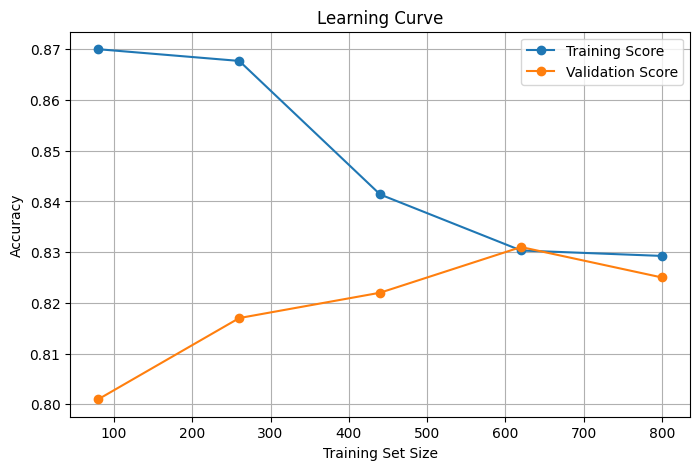

In [12]:
# Plot the learning curves

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training Score"
)

plt.plot(
    train_sizes,
    validation_mean,
    marker="o",
    label="Validation Score"
)

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.grid()

plt.show()

## W4D1 Observations

- A single train/test split provides only one estimate of model performance.
- K-Fold Cross-Validation evaluates the model across multiple train/validation splits.
- Stratified K-Fold is useful for classification because it approximately preserves class proportions in each fold.
- Precision measures how many predicted positive samples are actually positive.
- Recall measures how many actual positive samples are correctly identified.
- ROC-AUC measures the model's ability to distinguish between the positive and negative classes across classification thresholds.
- Learning curves help diagnose overfitting and underfitting by comparing training and validation performance as the training set grows.
- Cross-validation provides a more robust estimate of model performance than relying on a single train/test split.